# Sesi 09 - Pivot Tabel & Agregasi Lanjutan

Pivot tabel adalah cara merangkum data besar menjadi sesuati yang mudah dipahami dan dibaca
Di Excel mungkin kita sudah mengenalnya, nah di Python kita juga bisa melakukannya
Bahkan lebih powerful!

## 1. Load Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("samplesuperstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year

print("Shape: ", df.shape)
df.head(3)

Shape:  (10194, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,US-2023-103800,2023-01-03,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023
1,2,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023
2,3,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023


## 2. Pivot Tabel Dasar

In [9]:
# Pivot rata-rata Sales per category & region
pivot1 = df.pivot_table(
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

print(pivot1)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   164537.6518       168216.709  170416.312
East      212231.6960       211658.401  267938.071
South     117298.6840       125651.313  148771.908
West      260679.7295       226366.891  252766.988


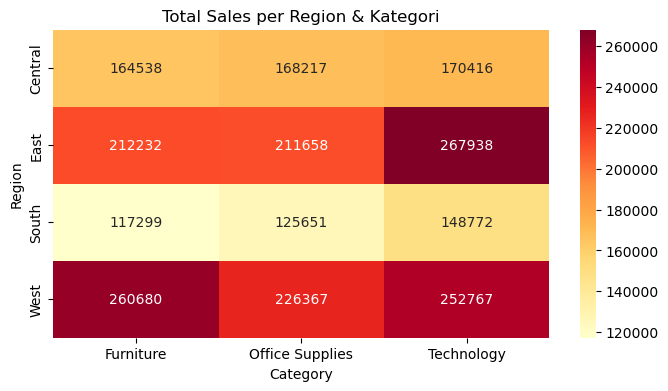

In [21]:
# Visualisasi pivot sebagai heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Total Sales per Region & Kategori")
plt.show()